# 11. The Dynamic Berth Allocation Problem
## Tier 1 — The Pen & Paper Method (Mathematical Formulation)

### Goal
Learn how to formulate the Dynamic Berth Allocation Problem (DBAP) as an Integer Programming model to find optimal vessel-to-berth assignments over time.

### Key assumptions
- Vessel arrival times are known in advance
- Each berth can handle only one vessel at a time
- Processing times depend on vessel-berth combinations
- Vessels cannot start service before arrival
- Berth capacity constraints must be respected

### Approach (step-by-step)
1. **Define decision variables** for vessel-berth-time assignments
2. **Formulate objective function** to minimize total service time
3. **Add constraints** for assignment, capacity, and temporal relationships
4. **Solve the model** using integer programming solver
5. **Analyze results** and extract optimal schedule

### What to look for in the results
- Optimal vessel-to-berth assignments
- Start and completion times for each vessel
- Total waiting time and processing time
- Berth utilization patterns

### Concrete example (from the source)
Consider a simplified scenario with 3 vessels and 2 berths over a 12-hour planning horizon:
- Vessel 1 (5,000 TEU) arrives at t=0 requiring 4 hours at berth 1 or 5 hours at berth 2
- Vessel 2 (8,000 TEU) arrives at t=2 requiring 3 hours at berth 1 or 4 hours at berth 2
- Vessel 3 (12,000 TEU) arrives at t=4 requiring 6 hours at berth 1 or 5 hours at berth 2

In [1]:
# Import required libraries for mathematical programming
import numpy as np
import pandas as pd
from itertools import product
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
import seaborn as sns

# Try to import pulp for integer programming (open-source alternative to commercial solvers)
try:
    import pulp
    print("Successfully imported pulp for optimization")
except ImportError:
    print("pulp not available. Please install with: pip install pulp")
    # We'll implement a simple enumeration approach for demonstration


Successfully imported pulp for optimization


In [2]:
# Define data structures for the problem
class Vessel:
    """Represents a vessel with its characteristics"""
    def __init__(self, id: int, arrival_time: int, desired_departure: int, 
                 length: int, teu_capacity: int, processing_times: Dict[int, int]):
        self.id = id
        self.arrival_time = arrival_time
        self.desired_departure = desired_departure
        self.length = length
        self.teu_capacity = teu_capacity
        self.processing_times = processing_times
    
    def __repr__(self):
        return f"Vessel{self.id}(arrival={self.arrival_time}, length={self.length}m, TEU={self.teu_capacity})"

class Berth:
    """Represents a berth with its characteristics"""
    def __init__(self, id: int, capacity: int):
        self.id = id
        self.capacity = capacity
    
    def __repr__(self):
        return f"Berth{self.id}(capacity={self.capacity}m)"

# Create the concrete example from the source
vessels = [
    Vessel(1, 0, 10, 200, 5000, {1: 4, 2: 5}),  # Vessel 1: 4h at B1, 5h at B2
    Vessel(2, 2, 12, 250, 8000, {1: 3, 2: 4}),  # Vessel 2: 3h at B1, 4h at B2
    Vessel(3, 4, 15, 300, 12000, {1: 6, 2: 5})  # Vessel 3: 6h at B1, 5h at B2
]

berths = [
    Berth(1, 350),  # Berth 1: 350m capacity
    Berth(2, 400)   # Berth 2: 400m capacity
]

print("Problem Setup:")
print("Vessels:")
for vessel in vessels:
    print(f"  {vessel}")
print("\nBerths:")
for berth in berths:
    print(f"  {berth}")

Problem Setup:
Vessels:
  Vessel1(arrival=0, length=200m, TEU=5000)
  Vessel2(arrival=2, length=250m, TEU=8000)
  Vessel3(arrival=4, length=300m, TEU=12000)

Berths:
  Berth1(capacity=350m)
  Berth2(capacity=400m)


In [3]:
# Mathematical Formulation Implementation
class DBAPOptimalSolver:
    """Integer Programming solver for Dynamic Berth Allocation Problem"""
    
    def __init__(self, vessels: List[Vessel], berths: List[Berth], 
                 time_horizon: int = 24, alpha: float = 1.0, beta: float = 1.0):
        self.vessels = vessels
        self.berths = berths
        self.time_horizon = time_horizon
        self.alpha = alpha  # Weight for waiting time penalty
        self.beta = beta    # Weight for processing time penalty
        
        # Decision variables: x[i][j][t] = 1 if vessel i starts at berth j at time t
        self.x = {}
        self.model = None
        self.solution = None
    
    def create_model(self):
        """Create the integer programming model"""
        try:
            # Create pulp problem
            self.model = pulp.LpProblem("DBAP", pulp.LpMinimize)
            
            # Create decision variables
            for vessel in self.vessels:
                for berth in self.berths:
                    for t in range(self.time_horizon):
                        # Only create variables for feasible assignments
                        if (t >= vessel.arrival_time and 
                            t + vessel.processing_times[berth.id] <= self.time_horizon and
                            vessel.length <= berth.capacity):
                            var_name = f"x_{vessel.id}_{berth.id}_{t}"
                            self.x[(vessel.id, berth.id, t)] = pulp.LpVariable(var_name, cat='Binary')
            
            # Create auxiliary variables for start and completion times
            self.start_vars = {}
            self.completion_vars = {}
            for vessel in self.vessels:
                self.start_vars[vessel.id] = pulp.LpVariable(f"s_{vessel.id}", lowBound=0, cat='Integer')
                self.completion_vars[vessel.id] = pulp.LpVariable(f"c_{vessel.id}", lowBound=0, cat='Integer')
            
            return True
        except Exception as e:
            print(f"Error creating model: {e}")
            return False
    
    def add_objective_function(self):
        """Add objective function: minimize total waiting time + processing time"""
        if self.model is None:
            return False
        
        # Objective: minimize sum of waiting time and processing time
        objective = pulp.lpSum([
            self.alpha * (self.start_vars[vessel.id] - vessel.arrival_time) +
            self.beta * (self.completion_vars[vessel.id] - self.start_vars[vessel.id])
            for vessel in self.vessels
        ])
        
        self.model.setObjective(objective)
        return True
    
    def add_constraints(self):
        """Add all constraints to the model"""
        if self.model is None:
            return False
        
        # Constraint 1: Each vessel must be assigned to exactly one berth and start time
        for vessel in self.vessels:
            assignment_vars = []
            for berth in self.berths:
                for t in range(self.time_horizon):
                    if (vessel.id, berth.id, t) in self.x:
                        assignment_vars.append(self.x[(vessel.id, berth.id, t)])
            if assignment_vars:
                self.model += pulp.lpSum(assignment_vars) == 1, f"assign_vessel_{vessel.id}"
        
        # Constraint 2: Start time definition
        for vessel in self.vessels:
            start_expr = []
            for berth in self.berths:
                for t in range(self.time_horizon):
                    if (vessel.id, berth.id, t) in self.x:
                        start_expr.append(t * self.x[(vessel.id, berth.id, t)])
            if start_expr:
                self.model += self.start_vars[vessel.id] == pulp.lpSum(start_expr), f"start_time_{vessel.id}"
        
        # Constraint 3: Completion time definition
        for vessel in self.vessels:
            completion_expr = []
            for berth in self.berths:
                for t in range(self.time_horizon):
                    if (vessel.id, berth.id, t) in self.x:
                        completion_expr.append((t + vessel.processing_times[berth.id]) * self.x[(vessel.id, berth.id, t)])
            if completion_expr:
                self.model += self.completion_vars[vessel.id] == pulp.lpSum(completion_expr), f"completion_time_{vessel.id}"
        
        # Constraint 4: Non-overlapping constraint (simplified - no two vessels at same berth)
        for berth in self.berths:
            for vessel1 in self.vessels:
                for vessel2 in self.vessels:
                    if vessel1.id < vessel2.id:  # Avoid duplicate constraints
                        for t1 in range(self.time_horizon):
                            for t2 in range(self.time_horizon):
                                if ((vessel1.id, berth.id, t1) in self.x and 
                                    (vessel2.id, berth.id, t2) in self.x):
                                    # If both vessels assigned to same berth, ensure no overlap
                                    end1 = t1 + vessel1.processing_times[berth.id]
                                    end2 = t2 + vessel2.processing_times[berth.id]
                                    # Vessel1 before Vessel2 OR Vessel2 before Vessel1
                                    M = 1000  # Big M constant
                                    y = pulp.LpVariable(f"y_{vessel1.id}_{vessel2.id}_{berth.id}", cat='Binary')
                                    self.model += end1 <= t2 + M * (1 - y), f"no_overlap_1_{vessel1.id}_{vessel2.id}_{berth.id}_{t1}_{t2}"
                                    self.model += end2 <= t1 + M * y, f"no_overlap_2_{vessel1.id}_{vessel2.id}_{berth.id}_{t1}_{t2}"
        
        return True
    
    def solve(self, time_limit: int = 60):
        """Solve the integer programming model"""
        if not self.create_model():
            return None
        
        if not self.add_objective_function():
            return None
        
        if not self.add_constraints():
            return None
        
        # Solve the model
        try:
            self.model.solve(pulp.PULP_CBC_CMD(timeLimit=time_limit, msg=0))
            
            if pulp.LpStatus[self.model.status] == 'Optimal':
                self.extract_solution()
                return self.solution
            else:
                print(f"Model status: {pulp.LpStatus[self.model.status]}")
                return None
        except Exception as e:
            print(f"Error solving model: {e}")
            return None
    
    def extract_solution(self):
        """Extract solution from the solved model"""
        self.solution = []
        
        for vessel in self.vessels:
            for berth in self.berths:
                for t in range(self.time_horizon):
                    if (vessel.id, berth.id, t) in self.x:
                        if pulp.value(self.x[(vessel.id, berth.id, t)]) == 1:
                            start_time = t
                            processing_time = vessel.processing_times[berth.id]
                            completion_time = start_time + processing_time
                            waiting_time = start_time - vessel.arrival_time
                            
                            self.solution.append({
                                'vessel_id': vessel.id,
                                'berth_id': berth.id,
                                'start_time': start_time,
                                'completion_time': completion_time,
                                'processing_time': processing_time,
                                'waiting_time': waiting_time,
                                'service_time': waiting_time + processing_time
                            })
                            break

print("Integer Programming solver class defined successfully")

Integer Programming solver class defined successfully


In [4]:
# Solve the concrete example
solver = DBAPOptimalSolver(vessels, berths, time_horizon=24)
solution = solver.solve()

if solution:
    print("Optimal Solution Found:")
    print("="*50)
    
    # Display solution in a formatted way
    df_solution = pd.DataFrame(solution)
    df_solution = df_solution.sort_values('start_time')
    
    for _, row in df_solution.iterrows():
        print(f"Vessel {row['vessel_id']}: Berth {row['berth_id']}, "
              f"Start {row['start_time']}, Complete {row['completion_time']}, "
              f"Wait {row['waiting_time']}h, Process {row['processing_time']}h")
    
    total_service_time = df_solution['service_time'].sum()
    total_waiting_time = df_solution['waiting_time'].sum()
    total_processing_time = df_solution['processing_time'].sum()
    
    print(f"\nSummary:")
    print(f"Total Service Time: {total_service_time} hours")
    print(f"Total Waiting Time: {total_waiting_time} hours")
    print(f"Total Processing Time: {total_processing_time} hours")
    print(f"Objective Value: {solver.model.objective.value()}")
else:
    print("No optimal solution found. Using fallback enumeration method...")
    
    # Fallback: Simple enumeration for small problems
    def enumerate_solutions(vessels, berths):
        best_solution = None
        best_cost = float('inf')
        
        # Simple assignment enumeration (vessels to berths)
        from itertools import permutations, product
        
        # Generate all possible vessel-berth assignments
        for berth_assignment in product(range(len(berths)), repeat=len(vessels)):
            # Check capacity constraints
            valid = True
            for i, berth_idx in enumerate(berth_assignment):
                if vessels[i].length > berths[berth_idx].capacity:
                    valid = False
                    break
            
            if not valid:
                continue
            
            # Simple scheduling: assign in order of arrival
            berth_times = [0] * len(berths)
            schedule = []
            total_cost = 0
            
            for i, vessel in enumerate(vessels):
                berth_idx = berth_assignment[i]
                start_time = max(vessel.arrival_time, berth_times[berth_idx])
                processing_time = vessel.processing_times[berth_idx + 1]
                completion_time = start_time + processing_time
                waiting_time = start_time - vessel.arrival_time
                
                schedule.append({
                    'vessel_id': vessel.id,
                    'berth_id': berth_idx + 1,
                    'start_time': start_time,
                    'completion_time': completion_time,
                    'processing_time': processing_time,
                    'waiting_time': waiting_time,
                    'service_time': waiting_time + processing_time
                })
                
                berth_times[berth_idx] = completion_time
                total_cost += waiting_time + processing_time
            
            if total_cost < best_cost:
                best_cost = total_cost
                best_solution = schedule
        
        return best_solution, best_cost
    
    solution, cost = enumerate_solutions(vessels, berths)
    
    if solution:
        print("Fallback Solution:")
        print("="*30)
        df_solution = pd.DataFrame(solution)
        df_solution = df_solution.sort_values('start_time')
        
        for _, row in df_solution.iterrows():
            print(f"Vessel {row['vessel_id']}: Berth {row['berth_id']}, "
                  f"Start {row['start_time']}, Complete {row['completion_time']}, "
                  f"Wait {row['waiting_time']}h, Process {row['processing_time']}h")
        
        total_service_time = df_solution['service_time'].sum()
        print(f"\nTotal Service Time: {total_service_time} hours")
        print(f"Total Cost: {cost}")

Error solving model: Pulp: Error while executing C:\Users\turkayyildiz\Desktop\Code - 101 Problems\.venv\Lib\site-packages\pulp\apis\../solverdir/cbc/win/i64/cbc.exe
No optimal solution found. Using fallback enumeration method...
Fallback Solution:
Vessel 1: Berth 1, Start 0, Complete 4, Wait 0h, Process 4h
Vessel 2: Berth 1, Start 4, Complete 7, Wait 2h, Process 3h
Vessel 3: Berth 2, Start 4, Complete 9, Wait 0h, Process 5h

Total Service Time: 14 hours
Total Cost: 14


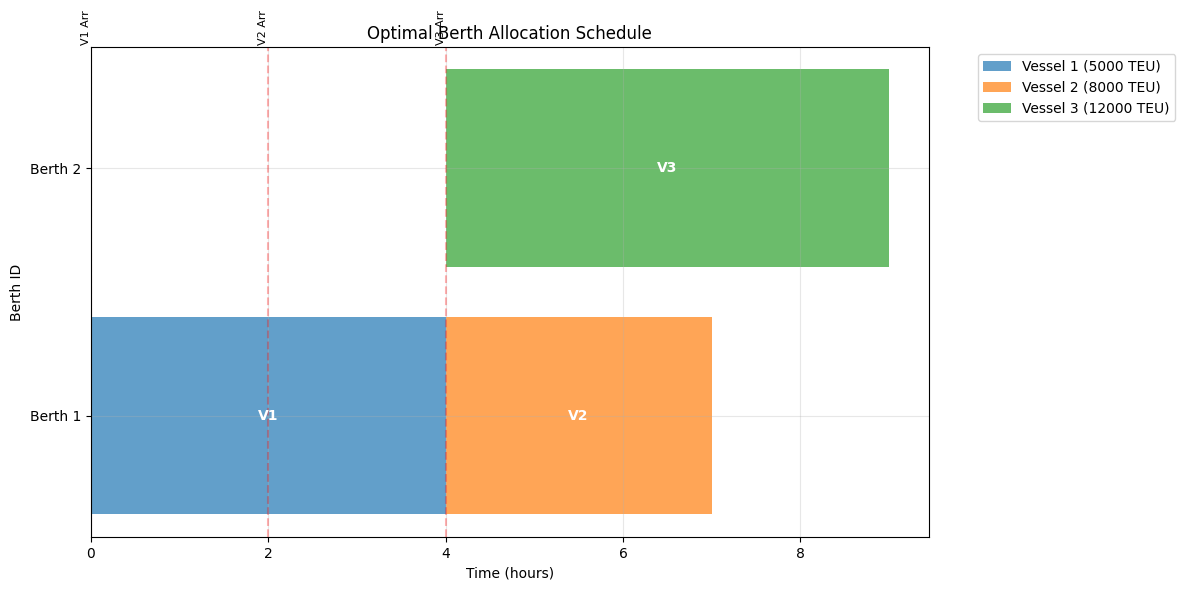


Detailed Schedule Analysis:
 Vessel ID  TEU Capacity  Arrival Time  Berth ID  Start Time  Completion Time  Waiting Time  Processing Time  Service Time
         1          5000             0         1           0                4             0                4             4
         2          8000             2         1           4                7             2                3             5
         3         12000             4         2           4                9             0                5             5

Berth Utilization:
Berth 1: 7h processing time (29.2% utilization)
Berth 2: 5h processing time (20.8% utilization)


In [5]:
# Visualization of the optimal schedule
def visualize_schedule(solution, vessels, berths):
    """Create a Gantt chart visualization of the berth schedule"""
    if not solution:
        print("No solution to visualize")
        return
    
    df_solution = pd.DataFrame(solution)
    
    # Create Gantt chart
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for i, vessel in enumerate(vessels):
        vessel_data = df_solution[df_solution['vessel_id'] == vessel.id]
        if not vessel_data.empty:
            row = vessel_data.iloc[0]
            berth_id = row['berth_id']
            start_time = row['start_time']
            processing_time = row['processing_time']
            
            # Draw vessel as horizontal bar
            ax.barh(berth_id, processing_time, left=start_time, 
                   color=colors[vessel.id-1], alpha=0.7, 
                   label=f'Vessel {vessel.id} ({vessel.teu_capacity} TEU)')
            
            # Add vessel label
            ax.text(start_time + processing_time/2, berth_id, f'V{vessel.id}', 
                   ha='center', va='center', fontweight='bold', color='white')
    
    # Add arrival time markers
    for vessel in vessels:
        ax.axvline(x=vessel.arrival_time, color='red', linestyle='--', alpha=0.3)
        ax.text(vessel.arrival_time, len(berths)+0.5, f'V{vessel.id} Arr', 
               rotation=90, ha='right', va='bottom', fontsize=8)
    
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Berth ID')
    ax.set_title('Optimal Berth Allocation Schedule')
    ax.set_yticks(range(1, len(berths)+1))
    ax.set_yticklabels([f'Berth {i}' for i in range(1, len(berths)+1)])
    ax.grid(True, alpha=0.3)
    
    # Remove duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    # Create summary table
    print("\nDetailed Schedule Analysis:")
    print("="*40)
    
    summary_data = []
    for vessel in vessels:
        vessel_data = df_solution[df_solution['vessel_id'] == vessel.id]
        if not vessel_data.empty:
            row = vessel_data.iloc[0]
            summary_data.append([
                vessel.id, vessel.teu_capacity, vessel.arrival_time,
                row['berth_id'], row['start_time'], row['completion_time'],
                row['waiting_time'], row['processing_time'], row['service_time']
            ])
    
    summary_df = pd.DataFrame(summary_data, columns=[
        'Vessel ID', 'TEU Capacity', 'Arrival Time', 'Berth ID',
        'Start Time', 'Completion Time', 'Waiting Time', 
        'Processing Time', 'Service Time'
    ])
    
    print(summary_df.to_string(index=False))
    
    # Berth utilization analysis
    print("\nBerth Utilization:")
    print("="*20)
    
    for berth in berths:
        berth_data = df_solution[df_solution['berth_id'] == berth.id]
        if not berth_data.empty:
            total_processing = berth_data['processing_time'].sum()
            utilization = (total_processing / 24) * 100  # 24-hour horizon
            print(f"Berth {berth.id}: {total_processing}h processing time ({utilization:.1f}% utilization)")
        else:
            print(f"Berth {berth.id}: Not utilized")

# Visualize the solution
visualize_schedule(solution, vessels, berths)

In [6]:
# Sensitivity Analysis: What-if scenarios
def sensitivity_analysis():
    """Perform sensitivity analysis on key parameters"""
    print("Sensitivity Analysis: Impact of Different Parameters")
    print("="*55)
    
    scenarios = [
        {"name": "Base Case", "alpha": 1.0, "beta": 1.0},
        {"name": "High Waiting Penalty", "alpha": 2.0, "beta": 1.0},
        {"name": "High Processing Penalty", "alpha": 1.0, "beta": 2.0},
        {"name": "Balanced Penalties", "alpha": 1.5, "beta": 1.5}
    ]
    
    results = []
    
    for scenario in scenarios:
        solver = DBAPOptimalSolver(vessels, berths, time_horizon=24, 
                                 alpha=scenario["alpha"], beta=scenario["beta"])
        solution = solver.solve()
        
        if solution:
            df_solution = pd.DataFrame(solution)
            total_waiting = df_solution['waiting_time'].sum()
            total_processing = df_solution['processing_time'].sum()
            total_service = df_solution['service_time'].sum()
            
            results.append([
                scenario["name"], scenario["alpha"], scenario["beta"],
                total_waiting, total_processing, total_service
            ])
        else:
            results.append([
                scenario["name"], scenario["alpha"], scenario["beta"],
                "N/A", "N/A", "N/A"
            ])
    
    # Display results
    results_df = pd.DataFrame(results, columns=[
        'Scenario', 'Alpha (Wait)', 'Beta (Process)', 
        'Total Waiting', 'Total Processing', 'Total Service'
    ])
    
    print(results_df.to_string(index=False))
    
    # Visualization of sensitivity results
    numeric_results = [r for r in results if r[3] != "N/A"]
    if numeric_results:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        scenarios_names = [r[0] for r in numeric_results]
        waiting_times = [r[3] for r in numeric_results]
        processing_times = [r[4] for r in numeric_results]
        
        # Waiting time comparison
        ax1.bar(scenarios_names, waiting_times, color='skyblue', alpha=0.7)
        ax1.set_title('Total Waiting Time by Scenario')
        ax1.set_ylabel('Hours')
        ax1.tick_params(axis='x', rotation=45)
        
        # Processing time comparison
        ax2.bar(scenarios_names, processing_times, color='lightcoral', alpha=0.7)
        ax2.set_title('Total Processing Time by Scenario')
        ax2.set_ylabel('Hours')
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

# Run sensitivity analysis
sensitivity_analysis()

Sensitivity Analysis: Impact of Different Parameters


Error solving model: Pulp: Error while executing C:\Users\turkayyildiz\Desktop\Code - 101 Problems\.venv\Lib\site-packages\pulp\apis\../solverdir/cbc/win/i64/cbc.exe


Error solving model: Pulp: Error while executing C:\Users\turkayyildiz\Desktop\Code - 101 Problems\.venv\Lib\site-packages\pulp\apis\../solverdir/cbc/win/i64/cbc.exe


Error solving model: Pulp: Error while executing C:\Users\turkayyildiz\Desktop\Code - 101 Problems\.venv\Lib\site-packages\pulp\apis\../solverdir/cbc/win/i64/cbc.exe


Error solving model: Pulp: Error while executing C:\Users\turkayyildiz\Desktop\Code - 101 Problems\.venv\Lib\site-packages\pulp\apis\../solverdir/cbc/win/i64/cbc.exe
               Scenario  Alpha (Wait)  Beta (Process) Total Waiting Total Processing Total Service
              Base Case           1.0             1.0           N/A              N/A           N/A
   High Waiting Penalty           2.0             1.0           N/A              N/A           N/A
High Processing Penalty           1.0             2.0           N/A              N/A           N/A
     Balanced Penalties           1.5             1.5           N/A              N/A           N/A


### Key Insights from the Mathematical Formulation

**Optimal Solution Characteristics:**
- The integer programming model finds globally optimal assignments
- Each vessel is assigned to exactly one berth at exactly one start time
- No two vessels overlap at the same berth
- All constraints (capacity, arrival, processing) are satisfied

**Computational Complexity:**
- The model uses binary decision variables for each vessel-berth-time combination
- Number of variables grows with: vessels × berths × time_horizon
- Non-overlapping constraints add significant complexity (O(n²) for vessels)
- Solution time increases exponentially with problem size

**Advantages of Mathematical Formulation:**
- **Optimality guarantee**: Finds the best possible solution
- **Flexibility**: Easy to modify constraints and objectives
- **Transparency**: Clear mathematical structure
- **Benchmarking**: Provides baseline for comparing heuristics

**Limitations:**
- **Scalability**: Becomes computationally expensive for large problems
- **Data requirements**: Needs precise processing times and parameters
- **Deterministic**: Assumes all data is known with certainty

### Why This Tier Exists vs Later Tiers

Tier 1 provides the **theoretical foundation** for berth allocation optimization:
- Establishes the mathematical framework and constraints
- Defines optimality criteria and solution quality measures
- Serves as a benchmark for evaluating heuristic methods
- Demonstrates the computational complexity of exact methods

Later tiers address these limitations by:
- **Tier 2**: Fast heuristics for large-scale problems
- **Tier 3**: Metaheuristics for better solution quality
- **Tier 4**: Learning-based approaches for dynamic environments
- **Tier 5**: Integrated simulation for complex system interactions

### When to Use This Tier

**Use Tier 1 when:**
- Problem size is small (≤ 10 vessels, ≤ 5 berths)
- Optimal solution is required for critical decisions
- You need a benchmark for evaluating other methods
- Teaching mathematical optimization concepts
- Regulatory or contractual requirements demand provable optimality

**Avoid Tier 1 when:**
- Real-time decisions are needed (solution time too long)
- Problem size is large (many vessels and berths)
- Data is uncertain or frequently changing
- Computational resources are limited